# Creating Label Data

Read all instructions before running this code!

This notebook is adapted from the MOSAIKS textbook [Label Data Demo](https://center-for-effective-global-action-cega.github.io/MOSAIKS-Training-Manual/en/en/part-01-labels/04-labels-demo.html) and Maddi's [adapted version for federal Superfund sites](https://colab.research.google.com/drive/1_kljqSfSz42T9AaKUD3usE7loG111k8I?usp=drive_link).

The MOSAIKS textbook version is an especially useful reference, because it explains what most of the code blocks are doing. The purpose of this notebook is to conveniently create label data, rather than explain how it is done.

To use this notebook, you will need to take several steps.
1. Find or upload the raw label data you want to this project's [GitHub repository](https://github.com/rachelmyoung/pollution-searching/tree/main/Data/Raw). It needs to be in the main branch, which you may require assistance depending on your permissions. The file needs to be a csv that contains, at minimum, a Superfund site in each row with a column for latitude (with "lat" as the header, no quotation marks) and longitude (with "lon" as the header, also with no quotation marks). If you are uploading it, give it a descriptive and concise name.
2. Make sure the MOSAIKS folder is shared with you on Google Drive. Once it has been shared (you can find it in the Shared With Me section in the toolbar on the left of the Google Drive home page), right click the folder, click "Organize", and then "Add Shortcut". IMPORTANT: You must add the shortcut to the highest level of your Google Drive directory; it cannot be in any folders.
3. Follow the additional instructions provided in the "Configuration Instructions" cell below. There are a few user inputs you will need to set up.
4. You must also put a file path in the final cell of this notebook, to instruct the code where to save your final labels.
# What Happens After I Run This Notebook?
Once you have created the final labels with this code, you will use Google Earth Engine and the [Featurizing in Google Earth Engine](https://colab.research.google.com/drive/1dqj4KOJckoV0ogrxGMZaiYTtYTcGHjgx?usp=drive_link) notebook to merge the labels with the features (a.k.a. featurizing the labels). You will be able to find the outputs of this notebook in [this folder](https://drive.google.com/drive/folders/1Gc-wHjrz6HrfFUj5x8myGvnPfFeElGC4?usp=drive_link).

In [1]:
%pip install rasterio
%pip install exactextract
%pip install mapclassify

In [2]:
import os
import shutil
import rasterio
import subprocess
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio.features
import matplotlib.pyplot as plt

from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile
from exactextract import exact_extract
from matplotlib.patches import Rectangle
from shapely.geometry import box, Polygon, MultiPolygon, GeometryCollection

# Configuration Instructions
The following cell allows you to configure which site data gets used and at which resolution we will merge labels with features.

Anyone, in theory, should be able to run this code. It requires a few steps.

1.   Set the "res" variable to the resolution you want. This notebook, in theory, should accept arbitrary resolutions, but the ones we are working with right now are 0.1, 0.01, and 0.001.
2.   Set the "file_path" variable to the raw file on GitHub you want. You can get the url to the raw file by going to the Data/Raw folder in this project's GitHub, selecting the file you want, and then right clicking the button that says Raw on the upper right part of the screen. Click "Copy link address" and then paste it over the url next to file_path in the code block below.
3.   In the final block of code all the way at the bottom, rewrite the drive location to match where you want your final data to be saved.

---

 **As a heads up**, "Raw" as in the name of the folder and "Raw" as in a raw file on GitHub do not refer to the same concept. The folder is named Raw, because it contains raw data without any processing or manipulation on our part. This name comes from our standards for project file organization. GitHub refers to raw files as files presented without any formatting or UI (whether they have been previously edited or not).

---

# Notes
* This script is designed such that anyone with the correct GitHub and Google Drive permissions can run it. Output files will append the date and time (down to the minute) so that people running it at roughly (though not exactly) the same time won't overwrite each other's files. This does mean you get a new pair of files *every time you run this script*. The folders these outputs point to can get very cluttered very quickly. In theory, a given set of raw labels should only need two associated files, so I will either change this system or we will need to be somewhat disciplined about making sure we're only keeping around the last few versions.
* The name of the output files are based on the name of the file taken from GitHub, so ideally those will be concise as well as descriptive.



In [3]:
### USER INPUT: PARAMETERS ###
# res can be 0.1, 0.01, or 0.005. Currently, 0.005 crashes because it uses up all available RAM.
# buff is declared here so we're doing math one time instead of potentially multiple times
res: float = 0.01 #input res here
buff = (res*5)/10

if res == 0.1:
  round_value: int = 2
  file_suffix = "_1"
elif res == 0.01:
  round_value: int = 3
  file_suffix = "_01"
elif res == 0.005:
  round_value: int = 4
  file_suffix = "_005"

### USER INPUT: SITE DATA DOWNLOAD ###
#input link to the .csv file you want to create labels out of
# this should be uploaded to GitHub first.
file_path = "https://github.com/rachelmyoung/pollution-searching/raw/refs/heads/main/Data/Raw/federal_superfund_spreadsheet.csv"

project_file = os.path.basename(file_path)
project_file = os.path.splitext(project_file)[0]
print(f"Filename without extension: {project_file}")

### USER INPUT: CONFIGURE LOCATION OF OUTPUT FILES ###
# IMPORTANT: you will need to add the MOSAIKS drive as a shortcut to your Google Drive in order of this to work.
# It needs to be added to a shortcut at the highest level of your Google Drive directory.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
output_path = "/content/drive/MyDrive/MOSAIKS/superfund_project_summer2026/Data/Intermediate/Spatial K Folds/Federal/" #where you want to save your final .csv

from datetime import date
from datetime import datetime


Filename without extension: federal_superfund_spreadsheet
Mounted at /content/drive


In [4]:
def create_grid(
    borders,
    resolution: float = res,
    geometry_col: str = "geometry",
    id_col: str = "NAME",
    return_ids: bool = False,
) -> pd.DataFrame:
    """
    Create a grid of latitude and longitude coordinates for one or more geometries.
    It can accept a bounding box, a single polygon (or other Shapely geometry),
    or a GeoDataFrame with a geometry column.

    Parameters
    ----------
    borders : list or tuple or shapely.geometry.BaseGeometry or geopandas.GeoDataFrame
        - If list/tuple of length 4, interpreted as a bounding box: [minx, miny, maxx, maxy].
        - If a Shapely geometry (Polygon, MultiPolygon, etc.), creates a single-row GeoDataFrame.
        - If a GeoDataFrame, the function iterates over its rows.
    resolution : float, optional
        Grid resolution in degrees, default 0.01.
    geometry_col : str, optional
        Column name for the geometry in the resulting GeoDataFrame, by default "geometry".
    id_col : str, optional
        Column name in the GeoDataFrame to use as the ID column, or the name
        for the new column if bounding box / single polygon is provided. Default is "NAME".
    return_ids : bool, optional
        If True, generate and return the unique IDs for each grid cell. This will create a
        column 'unique_id' which follows the pattern 'lon_{lon}__lat_{lat}'. This option slows
        down the overall operation. Default is False.

    Returns
    -------
    pd.DataFrame
        A DataFrame with columns:
        - 'lat': latitude values (Y)
        - 'lon': longitude values (X)
        - `[id_col]`: the identifier for each geometry feature
        - 'unique_id': a string combining [id_col] + lon/lat for uniqueness (optional)
    """

    # 1. Convert input to a GeoDataFrame
    gdf = _to_geodataframe(borders, geometry_col, id_col)

    # 2. Ensure there's an ID column in the GeoDataFrame
    if id_col not in gdf.columns:
        # If user didn't provide an ID col for bounding box or single geometry,
        # assign a placeholder ID. For a multi-row GDF, user is expected to pass
        # an existing column name.
        gdf[id_col] = [f"feature_{i}" for i in range(len(gdf))]

    # 3. Rasterize each geometry and collect points
    result_list = []
    for _, row in gdf.iterrows():
        geom = row[geometry_col]
        this_id = row[id_col]

        if geom.is_empty:
            # Skip empty geometries
            continue

        minx, miny, maxx, maxy = geom.bounds

        # ---- Create arrays for lat and lon values (Note: lat reversed) ----
        # The 0.005 shift ensures that coordinates align on .005
        lats = np.arange(
            np.ceil(maxy / resolution) * resolution - buff, miny, -resolution
        )
        lons = np.arange(
            np.ceil(minx / resolution) * resolution + buff, maxx, resolution
        )

        if len(lats) == 0 or len(lons) == 0:
            # If bounding box is too small or resolution is large, might be empty
            continue

        # ---- Create a meshgrid ----
        lon_grid, lat_grid = np.meshgrid(lons, lats)

        # ---- Rasterize the geometry ----
        out_shape = (len(lats), len(lons))
        transform = rasterio.transform.from_bounds(
            minx, miny, maxx, maxy, out_shape[1], out_shape[0]
        )

        mask = rasterio.features.rasterize(
            [(geom, 1)],
            out_shape=out_shape,
            transform=transform,
            fill=0,
            dtype=np.uint8,
        )

        # ---- Extract the lat and lon values using the mask ----
        lat_values = lat_grid[mask == 1]
        lon_values = lon_grid[mask == 1]

        # ---- Create a DataFrame and append to the result list ----
        temp_df = pd.DataFrame({"lat": lat_values, "lon": lon_values})
        temp_df[id_col] = this_id
        result_list.append(temp_df)

    # 4. Concatenate the results
    if len(result_list) == 0:
        final_result = pd.DataFrame(columns=["lat", "lon", id_col, "unique_id"])
    else:
        final_result = pd.concat(result_list, ignore_index=True)
        if return_ids:
            # --- Create the unique_id column ---
            # e.g. 'lon_-10.005__lat_9.995'
            final_result["lon_rounded"] = final_result["lon"].round(round_value).astype(str)
            final_result["lat_rounded"] = final_result["lat"].round(round_value).astype(str)

            final_result["unique_id"] = (
                "lon_"
                + final_result["lon_rounded"]
                + "__lat_"
                + final_result["lat_rounded"]
            )

            final_result.drop(["lon_rounded", "lat_rounded"], axis=1, inplace=True)

    return final_result


def _to_geodataframe(borders, geometry_col: str, id_col: str) -> gpd.GeoDataFrame:
    """
    Internal helper that converts various input types into a standardized GeoDataFrame.

    Parameters
    ----------
    borders : list/tuple, shapely geometry, or GeoDataFrame
        Bounding box (list/tuple of length 4),
        single Shapely geometry (Polygon, MultiPolygon, etc.),
        or a GeoDataFrame.
    geometry_col : str
        The name of the geometry column to use or create.
    id_col : str
        The column in which to store or look for an ID (if relevant).

    Returns
    -------
    gpd.GeoDataFrame
        A GeoDataFrame with columns [id_col, geometry_col].
    """
    # Case 1: bounding box
    if isinstance(borders, (list, tuple)) and len(borders) == 4:
        minx, miny, maxx, maxy = borders
        geom = box(minx, miny, maxx, maxy)
        gdf = gpd.GeoDataFrame(
            {id_col: ["bbox_1"], geometry_col: [geom]}, crs="EPSG:4326"
        )

    # Case 2: single shapely geometry
    elif isinstance(borders, (Polygon, MultiPolygon, GeometryCollection)):
        gdf = gpd.GeoDataFrame(
            {id_col: ["geom_1"], geometry_col: [borders]}, crs="EPSG:4326"
        )

    # Case 3: GeoDataFrame
    elif isinstance(borders, gpd.GeoDataFrame):
        # If geometry_col does not exist, rename the current geometry column
        # so everything is consistent
        if geometry_col not in borders.columns:
            borders = borders.rename(columns={borders.geometry.name: geometry_col})

        gdf = borders.copy()
        gdf = gdf.set_geometry(geometry_col)

    else:
        raise ValueError(
            "Unsupported input for 'borders'. Must be one of:\n"
            "1) [minx, miny, maxx, maxy]\n"
            "2) A Shapely geometry (Polygon, MultiPolygon, etc.)\n"
            "3) A GeoDataFrame"
        )

    return gdf

### Create a grid for a GeoDataFrame

#### Download the ADM0 dataset

In the following example, we create a grid for a GeoDataFrame with a geometry column. The grid will be created for the bounding box of each row, and then cropped to the geometry of that row. First, we load an example of a GeoDataFrame with a geometry column, two countries in this case. We then create a grid for each country and visualize the grid for each country.

This is slightly more practical use case, as it allows for the creation of a grid for multiple locations at once, while still minimizing the number of grid points that are created.


In [5]:


usa_adm0_fp= "https://gist.githubusercontent.com/krithin/7d694393e8a0b69dd3bd30336ecd46ad/raw/6a0d564a2dd5da4bfa5f035af25a36f6d35ccdf4/us_lower_48.geo.json"

usa_gdf = gpd.read_file(usa_adm0_fp)

print(f"Object type: {type(usa_gdf)}")

print(f"CRS: {usa_gdf.crs}")

print(f"Shape (row, col): {usa_gdf.shape}")


usa_gdf[["id", "name", "geometry"]]



Object type: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS: EPSG:4326
Shape (row, col): (1, 3)


,id,name,geometry
0,ContiguousUSA,United States of America - Lower 48 states,"POLYGON ((-94.81758 49.38905, -94.64 48.84, -9..."


#### Create the grid for Togo


In [6]:

usa_grid = create_grid(
    usa_gdf,
    resolution=res,
    geometry_col="geometry",
    id_col="id",
    return_ids=True,
)
usa_grid_gdf = gpd.GeoDataFrame(
    usa_grid,
    geometry=gpd.points_from_xy(usa_grid.lon, usa_grid.lat),
    crs="EPSG:4326",
)


usa_grid_gdf.geometry = usa_grid_gdf.geometry.buffer(buff, cap_style=3)

print(f"Shape (row, col): {usa_grid_gdf.shape}")


/tmp/ipykernel_15847/2952231105.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  usa_grid_gdf.geometry = usa_grid_gdf.geometry.buffer(buff, cap_style=3)


Shape (row, col): (8397327, 5)


### Area of each grid cell

Because our grid cells are defined in degrees, their actual area varies by latitude. Near the equator, each cell is approximately 1 km², while at higher latitudes the area decreases as the distance between meridians (longitude lines) converges. Below is a step-by-step outline for calculating and visualizing these differences:

1. Project and Calculate the Area

   - Convert the geometry to a projected Coordinate Reference System (CRS) with meters as the unit. Calculate the area of each grid cell (in m²), then convert to km².

1. Extract and Round Latitude

   - Create a new column containing the latitude of each grid cell, rounded to the nearest degree.

1. Visualize with a Boxplot
   - Group the data by rounded latitude (y-axis) and plot the corresponding area (x-axis) as a boxplot.

This becomes important when it comes time to aggregate features to larger polygons.


/tmp/ipykernel_15847/245295535.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


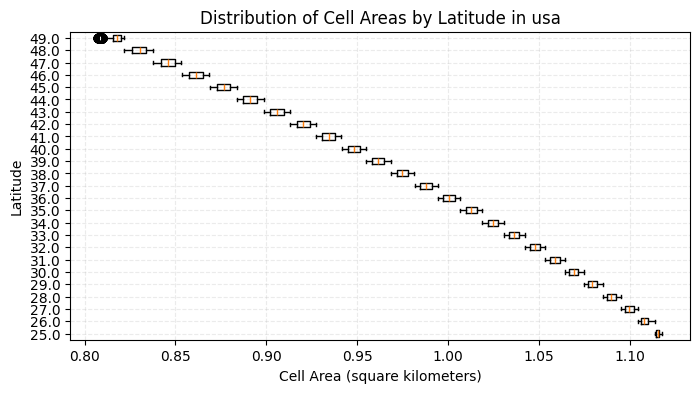

In [7]:
usa_grid_gdf["cell_area"] = usa_grid_gdf.to_crs("EPSG:5070").area / 10**6

usa_grid_gdf["lat_rounded"] = usa_grid_gdf["lat"].round(0)

plt.figure(figsize=(8, 4))

latitudes = sorted(usa_grid_gdf["lat_rounded"].unique())

plt.boxplot(
    [usa_grid_gdf.query("lat_rounded == @lat")["cell_area"] for lat in latitudes],
    labels=latitudes,
    vert=False,
)

plt.ylabel("Latitude")
plt.xlabel("Cell Area (square kilometers)")
plt.title("Distribution of Cell Areas by Latitude in usa")
plt.grid(True, linestyle="--", alpha=0.25)


#### Visualize the area of each grid cell

Now that we can see how the area of each grid cell changes with latitude, lets take a look at how this looks plotted as a color gradient on the map. We will plot the grid cells as polygons, with the color of each polygon representing the area of the grid cell.


In [8]:
'''
fig, ax = plt.subplots(figsize=(5, 9))

usa_gdf.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1,
)

usa_grid_gdf.plot(
    ax=ax,
    column="cell_area",
    cmap="viridis",
    legend=True,
    legend_kwds={"shrink": 0.9, "aspect": 50},
)

# invert the colorbar order to match the latitude
cbar = ax.get_figure().get_axes()[1]
cbar.invert_yaxis()

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.title("MOSAIKS grid cells over usa, colored by area")
plt.show()
'''

'\nfig, ax = plt.subplots(figsize=(5, 9))\n\nusa_gdf.boundary.plot(\n    ax=ax,\n    color="black",\n    linewidth=1,\n)\n\nusa_grid_gdf.plot(\n    ax=ax,\n    column="cell_area",\n    cmap="viridis",\n    legend=True,\n    legend_kwds={"shrink": 0.9, "aspect": 50},\n)\n\n# invert the colorbar order to match the latitude\ncbar = ax.get_figure().get_axes()[1]\ncbar.invert_yaxis()\n\nax.set_xlabel("Longitude")\nax.set_ylabel("Latitude")\nplt.title("MOSAIKS grid cells over usa, colored by area")\nplt.show()\n'

In [9]:
df = pd.read_csv(file_path, encoding='latin-1')
print(df.head())

ASSUMED_LAT_COLUMN = 'lat'
ASSUMED_LON_COLUMN = 'lon'

if 'df' in locals():
    try:
        labels_df = df[[
            ASSUMED_LAT_COLUMN,
            ASSUMED_LON_COLUMN
        ]].copy()

        labels_df = labels_df.rename(columns={
            ASSUMED_LAT_COLUMN: 'lat',
            ASSUMED_LON_COLUMN: 'lon'
        })

        labels_df['superfund'] = 1

        # Drop any rows that might be missing coordinates
        labels_df = labels_df.dropna(subset=['lat', 'lon'])

        # 1. Force conversion to numeric, turning text/garbage into NaN
        labels_df['lat'] = pd.to_numeric(labels_df['lat'], errors='coerce')
        labels_df['lon'] = pd.to_numeric(labels_df['lon'], errors='coerce')

        # 2. Drop the rows that were coerced to NaN (this removes the "lon/lat" string rows)
        before_count = len(labels_df)
        labels_df = labels_df.dropna(subset=['lat', 'lon'])
        after_count = len(labels_df)

        if before_count > after_count:
            print(f"Cleaned up {before_count - after_count} rows containing non-numeric text.")

        # 3. Double-check the types
        print(f"Data types:\n{labels_df.dtypes}")

        # You want to see: lat float64, lon float64
        print("--- Successfully processed data. ---")
        print("First 5 rows of your final label file:")
        print(labels_df.head())

        print("\nIndicator counts (all sites are '1'):")
        print(labels_df['superfund'].value_counts())

        ## SAVE THE FINAL LABELS

        output_filename = output_path + project_file + '_intermediatelabels' + file_suffix + '.csv'

        labels_df.to_csv(output_filename, index=False)

        print(f"\n--- Success! ---")
        print(f"Your final data has been saved to your Google Drive at:")
        print(output_filename)

    except KeyError as e:
        print(f"\n--- PROCESSING ERROR ---")
        print(f"A column name was not found: {e}")
        print("Please check your 'ASSUMED_...' variables in Section 1.")
        print("Make sure they *exactly* match the names from your file.")
    except Exception as e:
        print(f"An error occurred: {e}")

else:
    print("--- ERROR ---")

    row_id                 site_name    Unnamed: 2  \
0       10    EIELSON AIR FORCE BASE  AK1570028646   
1       10    ADAK NAVAL AIR STATION  AK4170024323   
2       10           FORT WAINWRIGHT  AK6210022426   
3  e Bent"                       NaN           NaN   
4       10  FORT RICHARDSON (USARMY)  AK6214522157   

                                      address Unnamed: 4             city  \
0           HIGHWAY 2 - 16 MI SE OF FAIRBANKS        NaN        FAIRBANKS   
1                                     ADAK IS        NaN             ADAK   
2                    RICHARDSON HWY, SE OF CY        NaN  FORT WAINWRIGHT   
3                                         NaN        NaN              NaN   
4  Postal Address is unavailable for the Site        NaN        ANCHORAGE   

  state    zip                county        lat  ...       Unnamed: 15  \
0    AK  99702  FAIRBANKS NORTH STAR  64.671450  ...  Waste Management   
1    AK  99546                   NaN  51.877500  ...            

In [10]:
drive_file_path = output_filename

usa_pois_gdf = pd.read_csv(os.path.join(drive_file_path))


print(f"Object type: {type(usa_pois_gdf)}")

print(f"Shape (row, col): {usa_pois_gdf.shape}")

usa_pois_gdf.head()

Object type: <class 'pandas.core.frame.DataFrame'>
Shape (row, col): (1721, 3)


,lat,lon,superfund
0,64.671450,-147.0492,1
1,51.877500,-176.6525,1
2,64.823000,-147.6106,1
3,61.258333,-149.7000,1
4,61.254169,-149.7917,1


In [11]:
# FIX THE DATAFRAME
print("Converting usa_pois_gdf to a GeoDataFrame...")
usa_pois_gdf = gpd.GeoDataFrame(
    usa_pois_gdf,
    geometry=gpd.points_from_xy(usa_pois_gdf['lon'], usa_pois_gdf['lat']),
    crs="EPSG:4326"
)

# CHECK THE CRSs
print(f"Grid CRS: {usa_grid_gdf.crs}")
print(f"Points CRS: {usa_pois_gdf.crs}")

if usa_grid_gdf.crs != usa_pois_gdf.crs:
    print("CRS mismatch. Re-projecting...")
    usa_pois_gdf = usa_pois_gdf.to_crs(usa_grid_gdf.crs)

#  RUN THE JOIN
print("Running spatial join...")
pois_grid = gpd.sjoin(
    usa_grid_gdf,
    usa_pois_gdf,
    how="inner",
    predicate="intersects"
)

#  CHECK THE OUTPUT
print(f"--- Join Complete! ---")
print(f"Total grid cells with points: {len(pois_grid)}")
print(pois_grid.head())

Converting usa_pois_gdf to a GeoDataFrame...
Grid CRS: EPSG:4326
Points CRS: EPSG:4326
Running spatial join...
--- Join Complete! ---
Total grid cells with points: 1658
       lat_left  lon_left             id                 unique_id  \
24126    48.915  -122.345  ContiguousUSA  lon_-122.345__lat_48.915   
29752    48.895  -122.355  ContiguousUSA  lon_-122.355__lat_48.895   
63517    48.775  -122.515  ContiguousUSA  lon_-122.515__lat_48.775   
72285    48.745  -119.555  ContiguousUSA  lon_-119.555__lat_48.745   
92250    48.675  -118.055  ContiguousUSA  lon_-118.055__lat_48.675   

                                                geometry  cell_area  \
24126  POLYGON ((-122.34 48.92, -122.34 48.91, -122.3...   0.815113   
29752  POLYGON ((-122.35 48.9, -122.35 48.89, -122.36...   0.815436   
63517  POLYGON ((-122.51 48.78, -122.51 48.77, -122.5...   0.817369   
72285  POLYGON ((-119.55 48.75, -119.55 48.74, -119.5...   0.817851   
92250  POLYGON ((-118.05 48.68, -118.05 48.67, -118.0..

#### Create label summaries

We then group the labels by the grid cell and count the number of labels in each grid cell. This will be our label summary.


In [12]:
# Group by grid cell (using lat/lon) and fclass, then count
pois_grid_count = pois_grid.groupby(
    ["lat_left", "lon_left", "unique_id"],
    as_index=False,
).unique_id.count()

# Rename the fclass column
pois_grid_count = pois_grid_count.rename(columns={
    "unique_id": "superfund",
    "lat_left": "lat",
    "lon_left": "lon"
    })
pois_grid_count["superfund"] = 1

pois_grid_count = gpd.GeoDataFrame(
    pois_grid_count,
    geometry=gpd.points_from_xy(pois_grid_count.lon, pois_grid_count.lat),
    crs="EPSG:4326",
)
pois_grid_count.geometry = pois_grid_count.geometry.buffer(buff, cap_style=3)
pois_grid_count



/tmp/ipykernel_15847/1603800095.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pois_grid_count.geometry = pois_grid_count.geometry.buffer(buff, cap_style=3)


,lat,lon,superfund,geometry
0,25.485,-80.395,1,"POLYGON ((-80.39 25.49, -80.39 25.48, -80.4 25..."
1,25.535,-80.415,1,"POLYGON ((-80.41 25.54, -80.41 25.53, -80.42 2..."
2,25.745,-80.315,1,"POLYGON ((-80.31 25.75, -80.31 25.74, -80.32 2..."
3,25.815,-80.255,1,"POLYGON ((-80.25 25.82, -80.25 25.81, -80.26 2..."
4,25.835,-80.345,1,"POLYGON ((-80.34 25.84, -80.34 25.83, -80.35 2..."
...,...,...,...,...
1613,48.675,-118.055,1,"POLYGON ((-118.05 48.68, -118.05 48.67, -118.0..."
1614,48.745,-119.555,1,"POLYGON ((-119.55 48.75, -119.55 48.74, -119.5..."
1615,48.775,-122.515,1,"POLYGON ((-122.51 48.78, -122.51 48.77, -122.5..."
1616,48.895,-122.355,1,"POLYGON ((-122.35 48.9, -122.35 48.89, -122.36..."


The following section actually creates the positive and negative labels with lat and long coordinates.

This is the section that you might want to change if you want specific types of labels.

For now, this is configured to make an equal number of positives and negatives, with the negatives being 2-neighbors-over on the west side of each positive label.

It then adds additional random 0s at the ratio of your choosing.

So for instance, you could have the equal number of 1s to 0s where the 0s are 2-neighbors-over as described above, plus 50% additional random 0s as there are 1s.

Read the notes carefully, as they will walk you through this block of code.

In [13]:
#CREATE 1s AND 0s

#PREPARE POSITIVE LABELS (the 1s)
labels_positive = pois_grid_count.rename(columns={"superfund": "indicator"})
labels_positive['indicator'] = 1
# Create a unique 'lat_lon_key'
labels_positive['lat_lon_key'] = labels_positive['lat'].astype(str) + '_' + labels_positive['lon'].astype(str)
print(f"Loaded {len(labels_positive)} positive (1s) rows.")


# PREPARE RANDOM % OF 0S (I.E. SAMPLE)
# Create the same unique 'lat_lon_key' on the full grid
usa_grid_gdf['lat_lon_key'] = usa_grid_gdf['lat'].astype(str) + '_' + usa_grid_gdf['lon'].astype(str)
# Get the list of keys that are already positive
positive_keys = labels_positive['lat_lon_key'].unique()
# Filter the full grid to find all rows that ARE NOT in the positive list
labels_negative = usa_grid_gdf[~usa_grid_gdf['lat_lon_key'].isin(positive_keys)].copy()
print(f"Found {len(labels_negative)} negative (0s) rows.")

### USER INPUT: PERCENT OF NEGATIVES TO POSITIVES IN DECIMAL FORM###
percent_negatives = 4.0 #(in decimal format; so if you want 50% additional 0s you would input 0.5 here. You can also put 0.)

#Determine negative sample size
sample_size = len(labels_positive) * (percent_negatives)
print(f"Sampling {sample_size} negative (0s) rows...")
#Randomly sample all negatives based on determined sample size
labels_negative_sample = labels_negative.sample(n=int(sample_size), random_state=42)
print(f"Sampled {len(labels_negative_sample)} negative (0s) rows.")
# Add the 'indicator' column with a value of 0
labels_negative_sample['indicator'] = 0

# PREPARE 2-OVER-NEIGHBOR ("SHIFTED") NEGATIVE POINTS
# We manually shift the coordinates west (-) by 0.02 points (i.e. 2 neighbors over)
#You could make this east by inputing + instead of -
labels_negative_neighbors = labels_positive.copy()
labels_negative_neighbors['lon'] = (labels_negative_neighbors['lon'] - 0.02).round(3)

#ADDS ALL NEGATIVE LABELS TOGETHER
labels_negative_points = pd.concat([labels_negative_neighbors, labels_negative_sample])

# Turn the shifted and negative coordinates into actual Point geometries
from shapely.geometry import Point
labels_negative_points['geometry'] = labels_negative_points.apply(
    lambda row: Point(row.lon, row.lat), axis=1
)
labels_negative_points = gpd.GeoDataFrame(labels_negative_points, crs="EPSG:4326")

# VALIDATE AGAINST THE ACTUAL GRID (Spatial Match)
# We use 'sjoin' to find which of our 'shifted' points actually land inside a grid cell.
# This ensures the negative cell is a real cell in your dataset.
valid_negatives = gpd.sjoin(
    labels_negative_points.drop(columns=['lat', 'lon']), # drop to avoid duplicates
    usa_grid_gdf[['lat', 'lon', 'geometry']],
    how="inner",
    predicate="intersects"
)

# Clean up: remove any negative that accidentally overlaps with a 1
# This happens if two Superfund sites are next to each other
positive_keys = labels_positive['lat'].astype(str) + labels_positive['lon'].astype(str)
valid_negatives['temp_key'] = valid_negatives['lat'].astype(str) + valid_negatives['lon'].astype(str)
final_negatives = valid_negatives[~valid_negatives['temp_key'].isin(positive_keys)].copy()

final_negatives['indicator'] = 0 #assigns all negative labels to indicator 0

# Combine
final_labels = pd.concat([
    labels_positive[['lat', 'lon', 'indicator']],
    final_negatives[['lat', 'lon', 'indicator']]
]).reset_index(drop=True)

# Check
print(f"Positives found: {len(labels_positive)}")
print(f"Valid Negatives found (after sampling): {len(final_negatives)}")
print(final_labels['indicator'].value_counts())

#See output text: it will tell you how many 1s and 0s your data will have.

Loaded 1618 positive (1s) rows.
Found 8395709 negative (0s) rows.
Sampling 6472.0 negative (0s) rows...
Sampled 6472 negative (0s) rows.
Positives found: 1618
Valid Negatives found (after sampling): 8070
indicator
0    8070
1    1618
Name: count, dtype: int64


In [14]:
final_labels = final_labels.round(round_value)
print(final_labels.head())
print(final_labels.tail())

      lat     lon  indicator
0  25.485 -80.395          1
1  25.535 -80.415          1
2  25.745 -80.315          1
3  25.815 -80.255          1
4  25.835 -80.345          1
         lat     lon  indicator
9683  38.585 -97.045          0
9684  31.975 -98.225          0
9685  43.615 -77.895          0
9686  47.135 -98.865          0
9687  34.065 -93.915          0


#### Visualize the label summaries

Finally, we visualize the label summaries. We plot the grid cells and color them by the number of labels in each cell. This will give us a sense of the distribution of labels across the country.


In [15]:
explore_final_labels = gpd.GeoDataFrame(
    final_labels,
    geometry=gpd.points_from_xy(final_labels.lon, final_labels.lat),
    crs="EPSG:4326",
)

##Unlock the next line if you want to see literally every point on a map:
#explore_final_labels.explore()

In [16]:
#Only samples on a map
pois_grid_count.explore()

#### Save the combined labels

Finally, we save the combined labels to a `feather` file in Google Drive. Feather is a fast, lightweight, and easy-to-use binary file format for storing data frames. It is particularly useful for sharing data between languages like Python and R. The Pandas package has built in support for reading and writing feather files with the `pd.read_feather` and `pd.to_feather` functions.

This step is optional, but we will use these later in the training manual to build models. If you would prefer to skip this step, there will be a link to download the file in those later notebooks, just as we downloaded data in this notebook.

If you prefer to use your own data, we need to connect to Google Drive. We will use the `google.colab` library to do this. Just set the `save_to_drive` variable to `True` and run the cell. You will be prompted to authenticate with your Google account and give the notebook permission to access your Google Drive. Once you have done this, the file will be saved to your Google Drive.

**Note:** If you are using this notebook in a language other than English, you may need to adjust the file path defined by `drive_directory` to match the name of the folder where you want to save the file in your Google Drive.


In [17]:
## USER INPUT: CHANGE NAME OF SAVED FILED IF YOU WANT##
file_suffix = file_suffix + "_" + str(date.today()) + "_" + str(datetime.now().hour) + str(datetime.now().minute) + "_" + "1to1neighbors_" + "400_percent"

save_to_drive = True

if save_to_drive:
    from google.colab import drive

    drive_dir = "/content/drive"

    drive.mount(drive_dir, force_remount=True)

    #USER INPUT: SAVE .CSV FILE TO DRIVE#
    drive_directory = os.path.join(
        drive_dir,
        "MyDrive",
        "MOSAIKS",
        "superfund_project_summer2026",
        "Data",
        "Intermediate",
        "Spatial K Folds",
        "Federal",
    )

    os.makedirs(drive_directory, exist_ok=True)

    file_path = os.path.join(drive_directory, project_file + "_finalcombinedlabels" + file_suffix + ".csv")

    final_labels.to_csv(file_path, index=False) #removes the index labels in the leftmost column because GEE doesn't work when there's an index.

Mounted at /content/drive


## Summary

The data we downloaded from Geofabrik contains many more files that we did not use. Take a look at the [Geofabrik documentation](https://download.geofabrik.de/osm-data-in-gis-formats-free.pdf) to see what other data is available. You can use the same workflows that we used in this notebook, though some further modifications may be necessary depending on the data you are working with.

We hope that these examples serve as a useful guide on how to think about label data and prepare labels for use in MOSAIKS. One of the hardest parts of data science is getting the data into the right format.
